# CIBUSmod example
This notebook privides a step-by-step example of how the model is run and how outputs can be visualised. The model is currently a work in progress, so this notebook will be continuosly updated as the work progresses.

## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import pandas as pd
import matplotlib.pyplot as plt

## Run scenario 'Food as industry'

### Set up scenario and modules

Instantiate a `Session` with a `name` and `data_path` to the folder with input data. Next add scenarios to run with `.add_scenario()`. Here we use a scenario defined in `data/scenarios/food_as_industry.xlsx` and calculate outputs for 5-year time-steps from 2020 to 2050.

In [3]:
# Create session
session = cm.Session(
    name = 'MFF_scenarios',
    data_path = '../data'
)

# Define scenarios
session.add_scenario(
    name = 'baseline',                        # Name of scenario in outputs
    scenario_workbooks = None,                # Name of scenario Excel file
    modules = 'all',                          # Modules to update
    pars = 'all',                             # Parameters to update
    years = '2020'                            # Years to calculate
)

session.add_scenario(
    name = 'FAI',
    scenario_workbooks = 'food_as_industry',
    modules = 'all',
    pars = 'all',
    years = '2050'
)
session.add_scenario(
    name = 'FAC',
    scenario_workbooks = 'food_as_culture',
    modules = 'all',
    pars = 'all',
    years = '2050'
)
session.add_scenario(
    name = 'FAT',
    scenario_workbooks = 'food_as_tech',
    modules = 'all',
    pars = 'all',
    years = '2050'
)
session.add_scenario(
    name = 'FF',
    scenario_workbooks = 'food_forgotten',
    modules = 'all',
    pars = 'all',
    years = '2050'
)

session.add_scenario(
    name = 'FAI_no_cows',
    # Here a list of scenario workbooks are provided. These are handled in consequtive order
    # and if the same parameter is updated in sevral workbooks only the latest in
    # the list will have an effect.
    scenario_workbooks = ['food_as_industry', 'no_cows'], 
    modules = 'all',
    pars = 'all',
    years = '2050'
)

A scenario with the name 'baseline' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAI' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAC' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAT' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FF' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAI_no_cows' already exists use .update_scenario() or .remove_scenario() instead.


Next, we initialise all model modules (python classes) that handle the calculations.

Each module is intialised with a `ParameterRetriever` object which reads a named parameter Excel-file from the default data folder and handles the retrieval of parameter values used in the calculations. The `ParameterRetriever` also handles updating parameter values according to a scenario.

There are four main modules that store data as attributes (generaly in the form of pandas.DataFrames). These are:

`Regions`
This module handles baselina crop areas and animal numbers ('x0') as well as various regional attrubutes such as climate and soil properties.

`DemandAndConversions`
This module calculates demand for crop and animal production based on population, consumption of different foods, waste and conversion factors, etc. It also calculates waste and by-products generated.

`CropProduction`
This module calculates production of crop products per unit (area) of a certain crop in a certain region.

`AnimalHerd`
This module has subclasses for each animal species (and breed) and is initialised as one AnimalHerd object per combination of species (e.g. cattle), breed (e.g. dairy), production system (e.g. conventional) and sub system (used to represent different feeding strategies, e.g. maize based). The `AnimalHerd` modules calculates production of animal products per animal unit (i.e. a defining animal in the species/breed). The defining animal differs accros species/breeds with e.g. 'cows' for `CattleHerd`s, 'sows+gilts' for `PigHerd`s and 'total horses' for `HorseHerd`s.

There are also a number of management (mgmt) modules that calculates specific aspects on the main modules. These have no data attributes but do have their own parameter Excel-files connected to them. These are:

`FeedMgmt`
Handles the calculation of feed requirements, losses and import shares and the translation from 'feed products' to 'crop products' and 'by-products'.

`ManureMgmt`
Handles the calculation of manure excretion and losses in stables and storage.

`PlantNutrientMgmt`
Handles the calculation of crop fertiliser requirements (N, P and K) and application of manure and mineral fertiliser.

`MachineryAndEnergyMgmt`
Handles the calculation of energy requirements in machinery, drying, greenhouses, stables etc.

`InputsMgmt`
Handles the calculation of supply chain emissions for inputs (currently energy and fertilisers) by retrieving lifecycle inventory data from ecoinvent.

Finaly the module `GeoDistributor` handles the distribution of crop and animal production across regions by solving a convex optimisation problem that minimises the deviation of crop areas and animal numbers for the current situation while meeting demand for crop and animal products as wel as a number of additional constraints.

In [4]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

### Run calculations
Now we have initialised all modules and can do the calculations. This is done by looping through scenarios and years via `Session.iterate()` and first updating all parameter values according to the speciefied scenario and year via `ParameterRetriever.update_all_parameter_values()` and then (re-)calculating all modules. After all main modules have been (re-)calculated we run `GeoDistributor.make()` and `GeoDistributor.solve()` to make and solve the optimisation problem that distribute crops and animals across regions. Then some mgmt modules are calculated and finally ouputs are stored via `Session.store()` before the next iteration.

In [ ]:
# Set to true to print progress messages
msg = True

# Loop through scenarios and years
for scn, year in session.iterate('all'):#
    print(scn,year)
    
    # Update all parameter values
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year = year
    )
    
    # Get region attributes
    regions.calculate(verbose=msg)
    
    # Calculate food demand
    demand.calculate(verbose=msg)
    
    # Calculate crops
    crops.calculate(
        verbose=msg
    )
    
    # Calculate herds
    for h in herds:
        h.calculate(verbose=msg)

    # Induce beef exports in DemandAndConversions if beef production from dairy
    # systems under given demand for milk products exceeds total beef demand.
    # This is to avoid not finding any solution when running the GeoDistributor.
    cm.helpers.induce_beef_exports(
        demand = demand,
        herds = herds
    )

    # Calculate feed
    feed_mgmt.calculate(verbose=msg)    
    
    # Distribute animals and crops
    # Make optimisation problem
    geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.4, verbose=msg)
    # Solve optimisation problem (move to next scn/year if it fails)
    try:
        geodist.solve(verbose=msg)
    except Exception as e:
        print(f'(!!!) GeoDistributor failed for {scn}, {year} with the exception: {e}')
        continue
    
    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=msg)
    
    # Calculate manure
    manure_mgmt.calculate(verbose=msg)
    
    # Calculate harvest of crop residues
    crop_residue_mgmt.calculate(verbose=msg)

    # Calculate treatment of wastes and other feedstocks
    waste.calculate(verbose=True)
    
    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=msg)
    
    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=msg)
    
    # Calculate inputs supply chain emissions
    inputs.calculate(verbose=msg)
    
    # Store results
    session.store(
        scn, year,
        demand, regions, crops, waste, herds
    )

### Look at the data

Use `Session` to get a summary of scenarios and modules and their data attributes.

In [ ]:
session

Use `Session.get_attr()` to retrieve specific data for all scenarios and years.

In [5]:
session.get_attr(
    module='c',
    attr='area',
    groupby={'crop':'land_use'},
)/1000

,land_use,cropland,greenhouse,semi-natural grasslands
scn,year,,,
baseline,2020,2565.123388,1385.059588,449.155410
FAI,2050,2550.873689,3661.385608,514.709281
FAC,2050,3237.426404,2458.953911,529.460747
FAT,2050,1743.980304,951.195062,275.808755
FF,2050,1585.284108,911.758245,198.489112
FAI_no_cows,2050,1751.901446,3637.595171,152.610819


In [6]:
session.get_attr(
    module='A',
    attr='heads',
    groupby='species'
)/1000

,species,cattle,horses,pigs,poultry,sheep
scn,year,,,,,
baseline,2020,1453.106426,355.500018,1410.833678,24505.185675,412.373412
FAI,2050,1559.816937,355.500000,1588.134400,22949.520173,921.275678
FAC,2050,1714.357760,355.500737,220.856106,13058.177387,319.510616
FAT,2050,810.738574,355.500093,0.000000,4016.988625,108.729911
FF,2050,388.906650,355.500116,672.135542,20983.798347,85.641595
FAI_no_cows,2050,0.000000,355.500596,1588.134400,22949.520173,921.275678


## Plot output
Here are some example output plots.

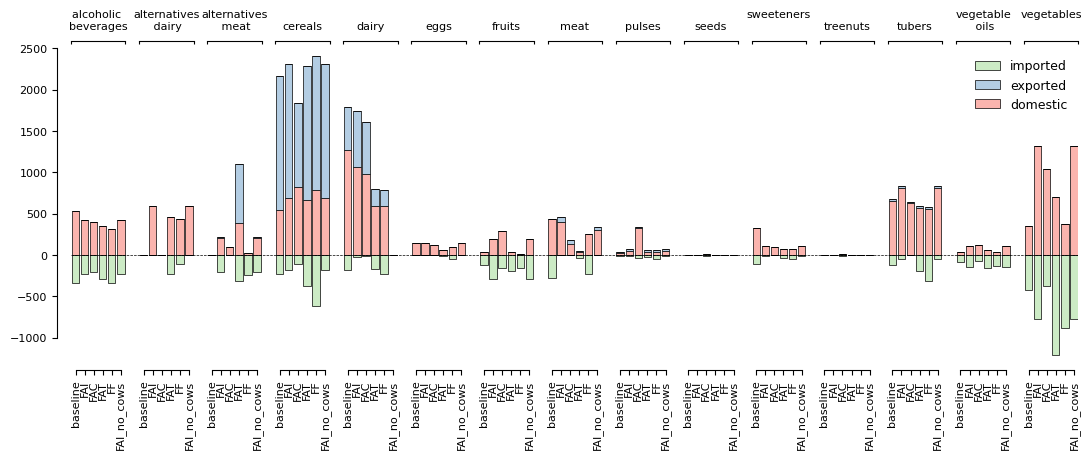

In [8]:
plot_data = (
    session.get_attr(
        module='D',
        attr='food_demand_to_processing',
        groupby=['origin','food_group']
    ).add(
        session.get_attr(
            module='D',
            attr='export_demand',
            groupby=['origin','food_group']
        ).rename(columns={'domestic':'exported'}),
        fill_value = 0
    )
    .stack()
    .fillna(0)
    .droplevel('year')
)/1000000
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']

fig, ax = plt.subplots(figsize=(13,4))
cm.plot.bar(
    plot_data, ax=ax,
    group_levels='food_group',
    group_spacing=1.5,
    totmarker='none',
    grouplabels_fontsize=8,
    ticklabels_fontsize=8,
    cmap='Pastel1'
)
plt.show()

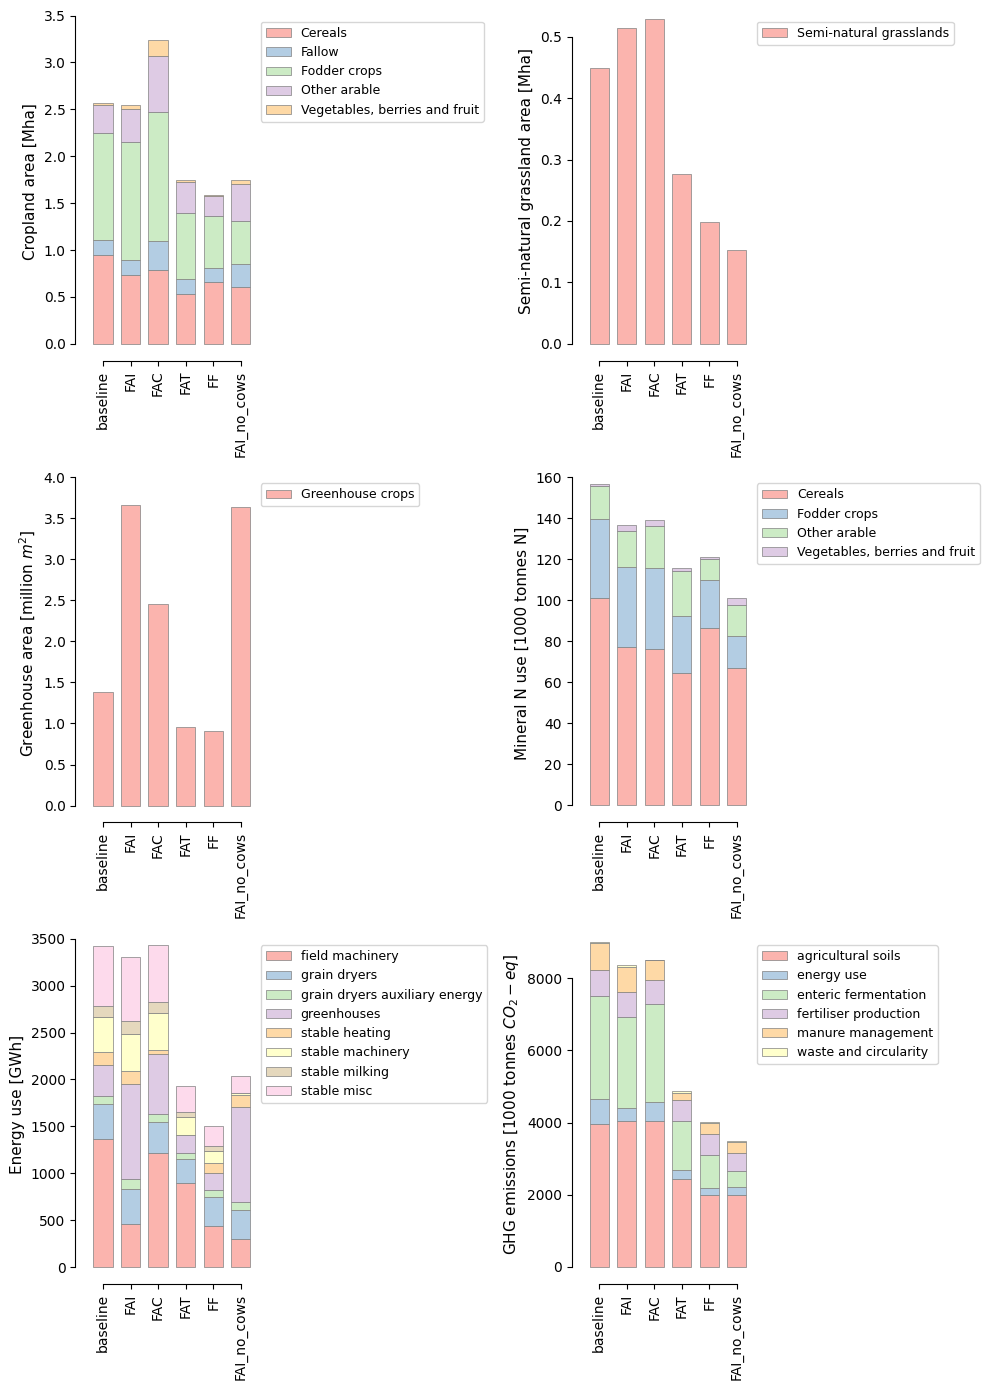

In [9]:
style = {
    'stacked' : True,
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.7
}

fig, axs = plt.subplots(3,2, figsize=(10,14))

# Land use --->
plot_data = session.get_attr('C','area',{'crop':'crop_group2'}).droplevel('year')/1000000

# Cropland
ax = axs[0,0]
plot.bar(
    plot_data.drop(['Semi-natural grasslands','Greenhouse crops'], axis=1),
    **style,
    ax=ax,
    ylabel='Cropland area [Mha]'
)

# Semi-natural grassland
ax = axs[0,1]
plot.bar(
    plot_data.xs('Semi-natural grasslands', axis=1),
    **style,
    ax=ax,
    ylabel='Semi-natural grassland area [Mha]'
)

# Greenhouse
ax = axs[1,0]
plot.bar(
    plot_data.xs('Greenhouse crops', axis=1),
    **style,
    ax=ax,
    ylabel=r'Greenhouse area [million $m^2$]'
)

# Mineral N use --->
ax = axs[1,1]
plot.bar(
    (session.get_attr('C','fertiliser.mineral_N',{'crop':'crop_group2'})/1000000).droplevel('year'),
    **style,
    ax=ax,
    ylabel='Mineral N use [1000 tonnes N]'
)

# Energy use --->
ax = axs[2,0]
plot.bar(
    pd.concat([
        session.get_attr('C','energy_use','activity'),
        session.get_attr('A','energy_use','activity')
    ], axis=1).droplevel('year')/1000000,
    **style,
    ax=ax,
    ylabel='Energy use [GWh]'
)

# GHG emissions
ax = axs[2,1]
plot_data = (
    cm.get_GHG(session)
    .T.groupby('process').sum().T
    .droplevel('year')
)/1000000
plot.bar(
    plot_data,
    **style,
    ax=ax,
    ylabel=r'GHG emissions [1000 tonnes $CO_{2}-eq$]'
)

for ax in axs.flatten():
    ax.legend(loc='upper left', ncol=1, bbox_to_anchor=(1, 1), fontsize=9)

plt.tight_layout()
plt.show()

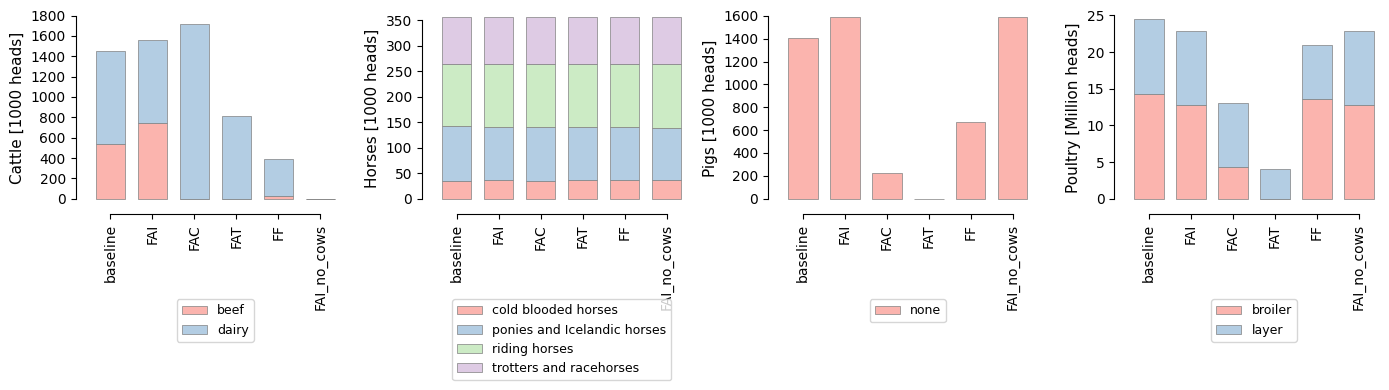

In [10]:
style = {
    'stacked' : True,
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.7
}
    
# Number of animal heads
plot_data = session.get_attr('A','heads',['species','breed']).droplevel('year')

fig, axs = plt.subplots(1,4, figsize=(14,5))

for ax,sp in zip(axs,plot_data.columns.get_level_values('species').unique()):

    plot.bar(
        (plot_data / (1000000 if sp=='poultry' else 1000))
        .xs(sp, level='species', axis=1),
        **style,
        ax=ax,
        ylabel=sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]')
    )

for ax in axs.flatten():
    ax.legend(loc='upper center', ncol=1, bbox_to_anchor=(0.5, -0.5), fontsize=9)

plt.tight_layout()
plt.show()

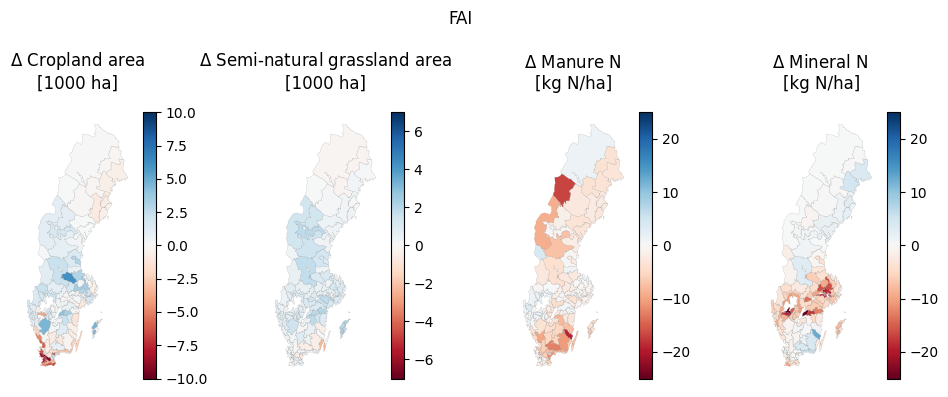

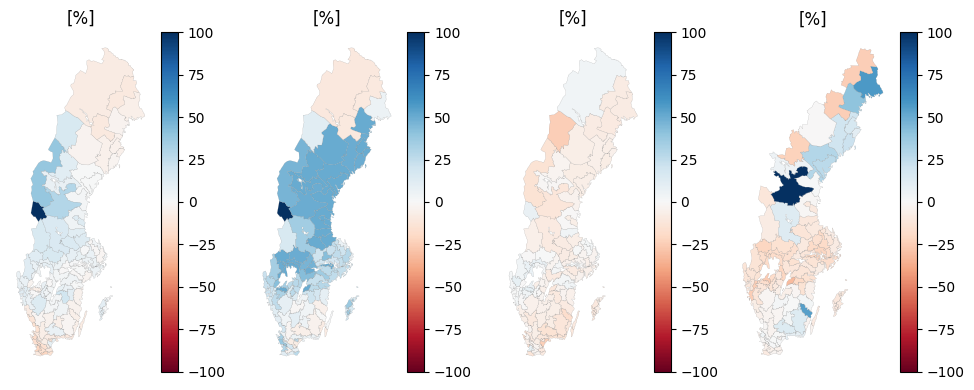

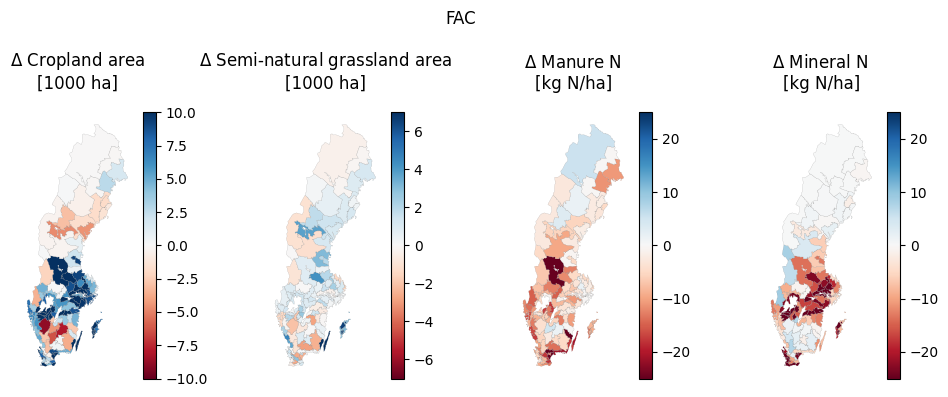

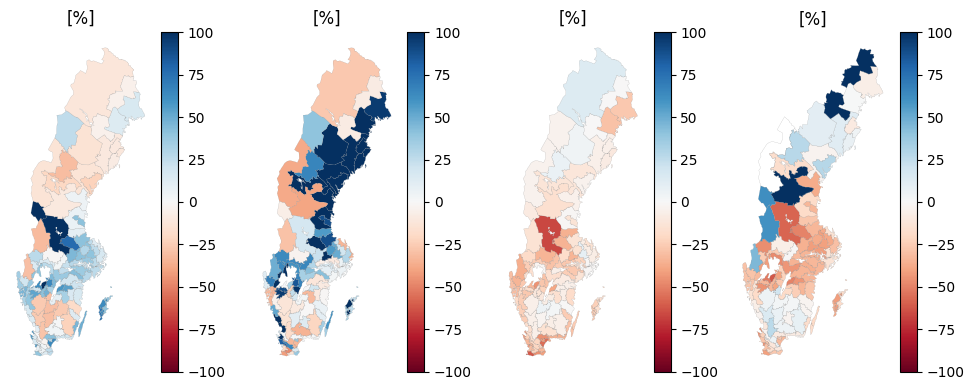

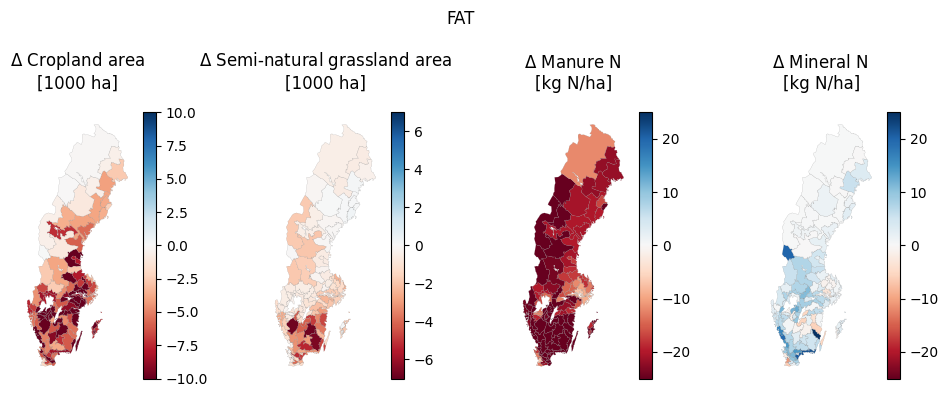

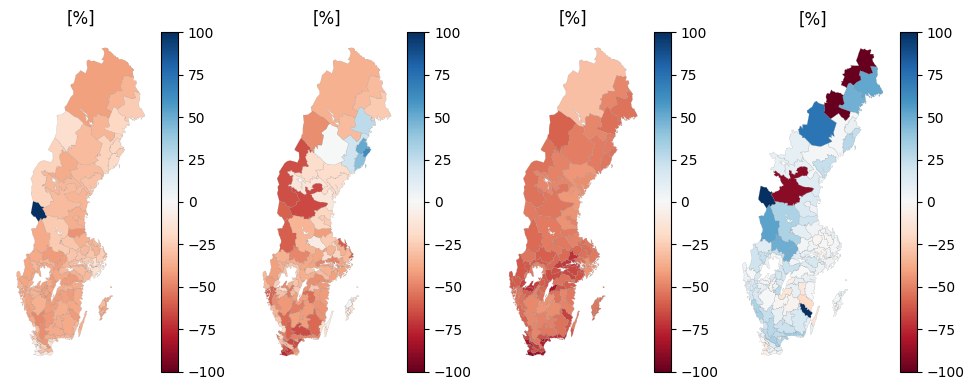

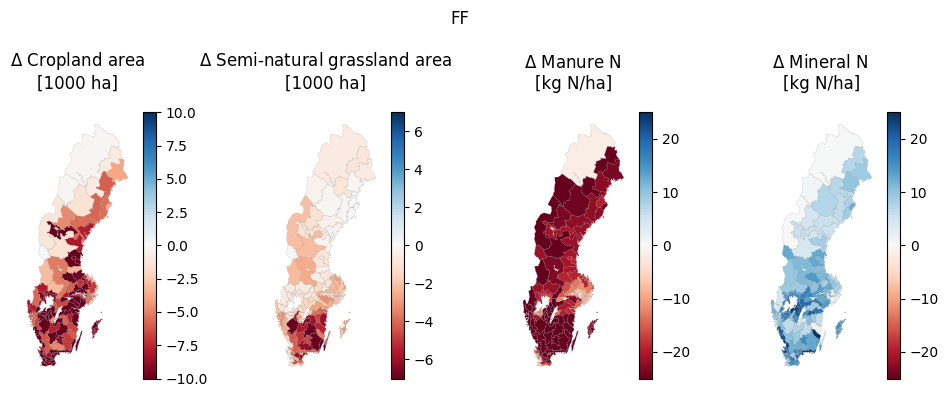

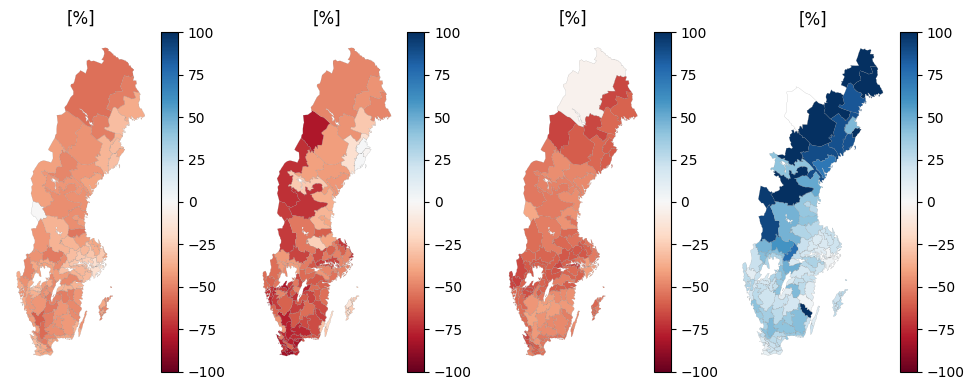

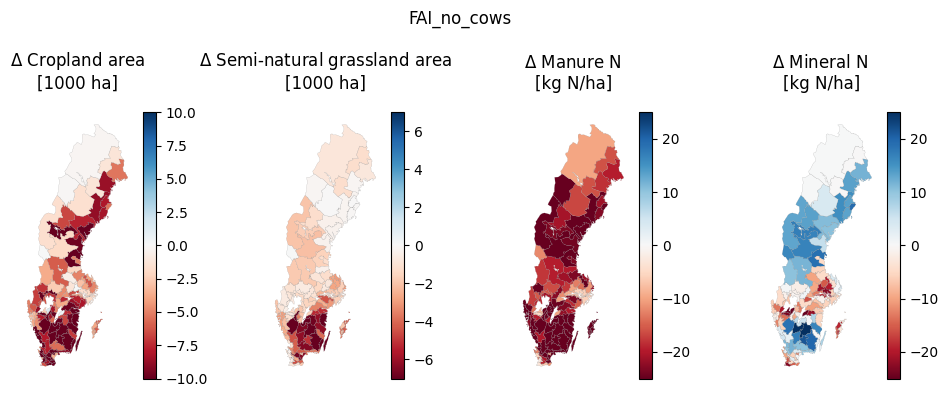

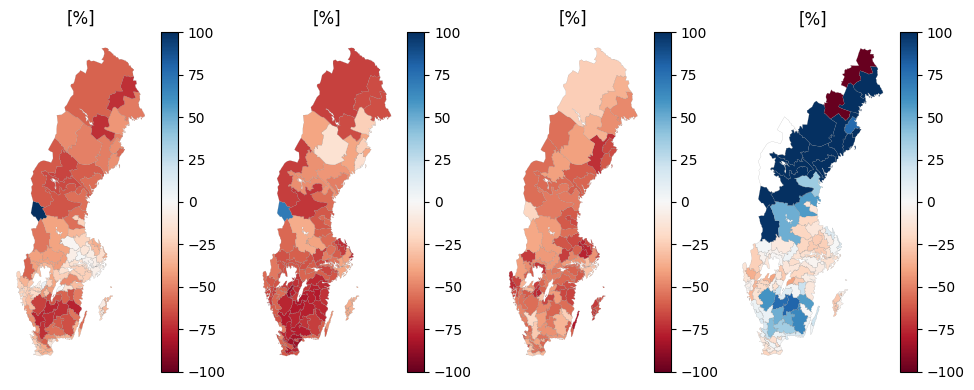

In [11]:
y0 = session.scenarios()['baseline'][0]
scns = [s for s in session.scenarios() if s != 'baseline']
for scn in scns:
    
    yend = session.scenarios()[scn][-1]

    # ABSOLUTE
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = session.get_attr('C','area',{'crop':'land_use','region':None})/1000
    plot_data = plot_data.loc[(scn,yend)] - plot_data.loc[('baseline',y0)]
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-10,
        vmax=10,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Cropland area\n[1000 ha]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-7,
        vmax=7,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Semi-natural grassland area\n[1000 ha]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = session.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[:,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[:,'cropland']
    plot_data = plot_data.loc[(scn,yend)] - plot_data.loc[('baseline',y0)]
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Manure N \n[kg N/ha]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = session.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[:,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[:,'cropland']
    plot_data = plot_data.loc[(scn,yend)] - plot_data.loc[('baseline',y0)]
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Mineral N \n[kg N/ha]')
    ax.set_axis_off()

    
    plt.suptitle(scn)
    plt.tight_layout()
    plt.show()

    # PERCENT
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = session.get_attr('C','area',{'crop':'land_use','region':None})/1000
    plot_data = (plot_data.loc[(scn,yend)] - plot_data.loc[('baseline',y0)]) / plot_data.loc[('baseline',y0)] * 100
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('[%]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('[%]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = session.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[:,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[:,'cropland']
    plot_data = (plot_data.loc[(scn,yend)] - plot_data.loc[('baseline',y0)]) / plot_data.loc[('baseline',y0)] * 100
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('[%]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = session.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[:,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[:,'cropland']
    plot_data = (plot_data.loc[(scn,yend)] - plot_data.loc[('baseline',y0)]) / plot_data.loc[('baseline',y0)] * 100
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('[%]')
    ax.set_axis_off()
   
    plt.tight_layout()
    plt.show()

baseline
--------


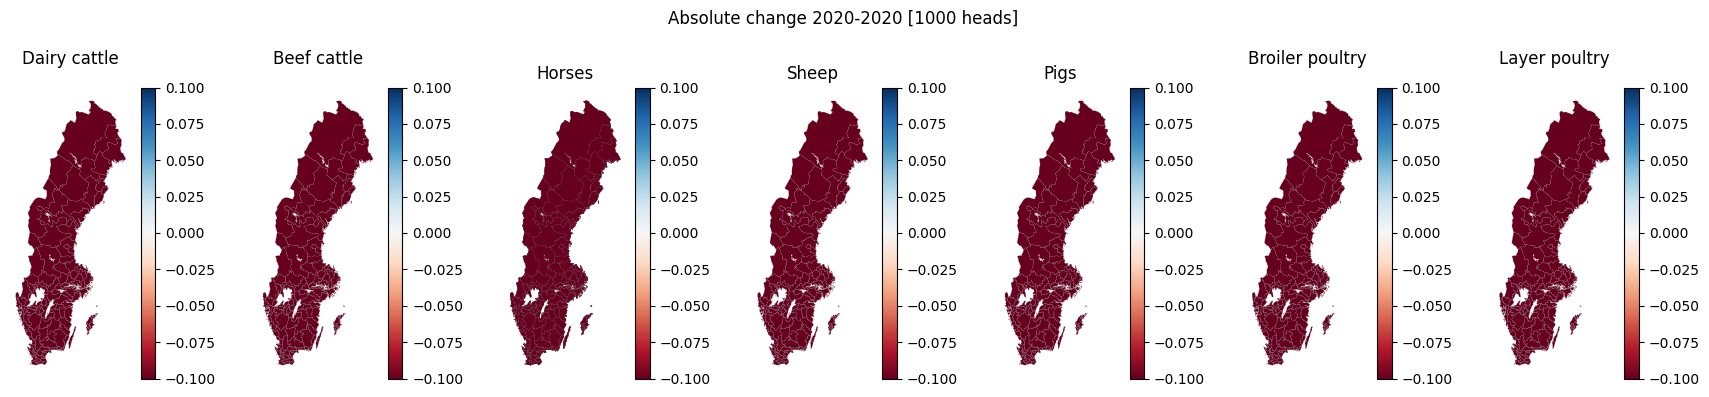

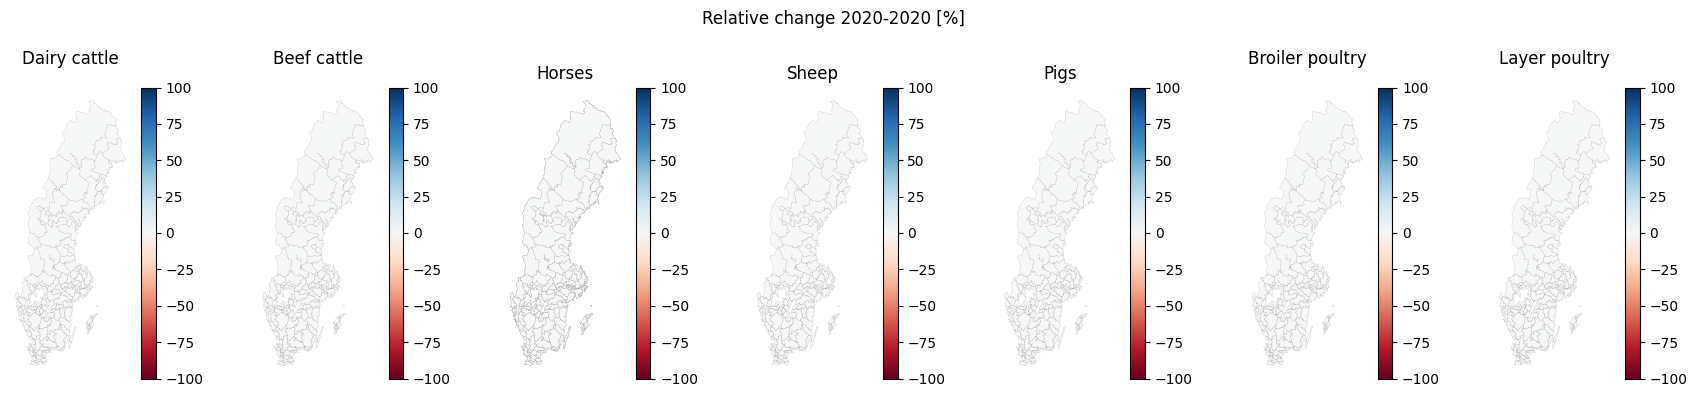

FAI
---


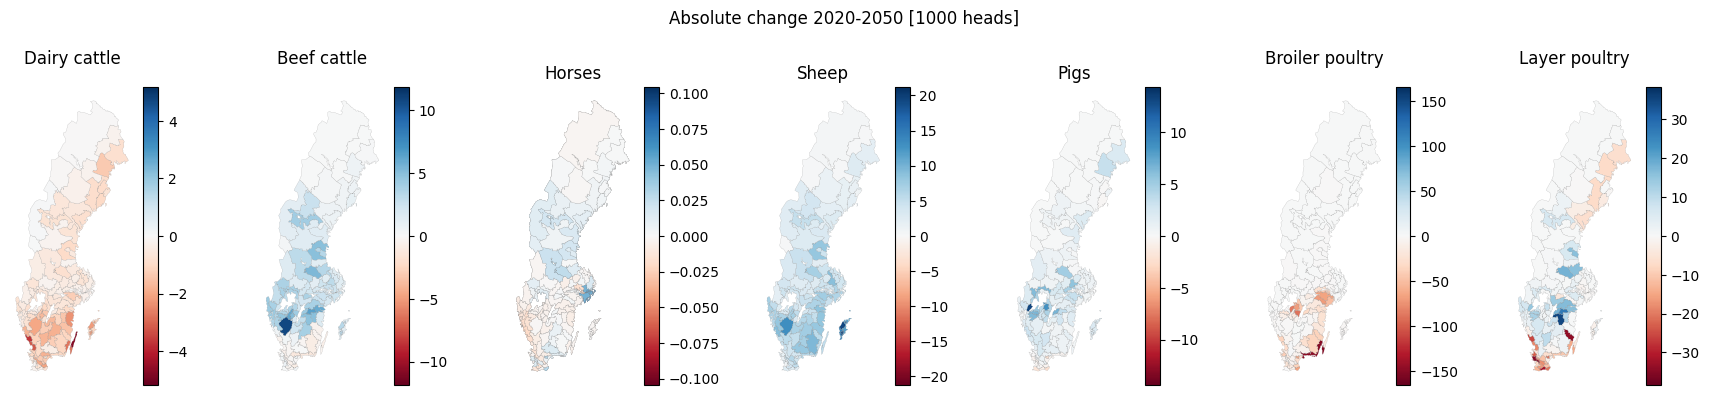

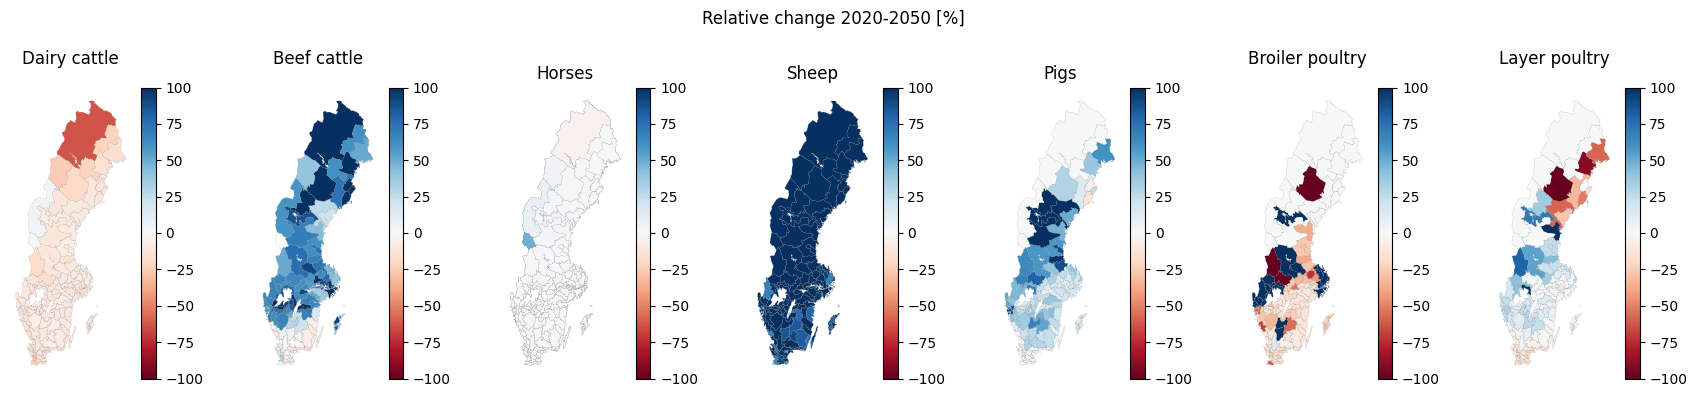

FAC
---


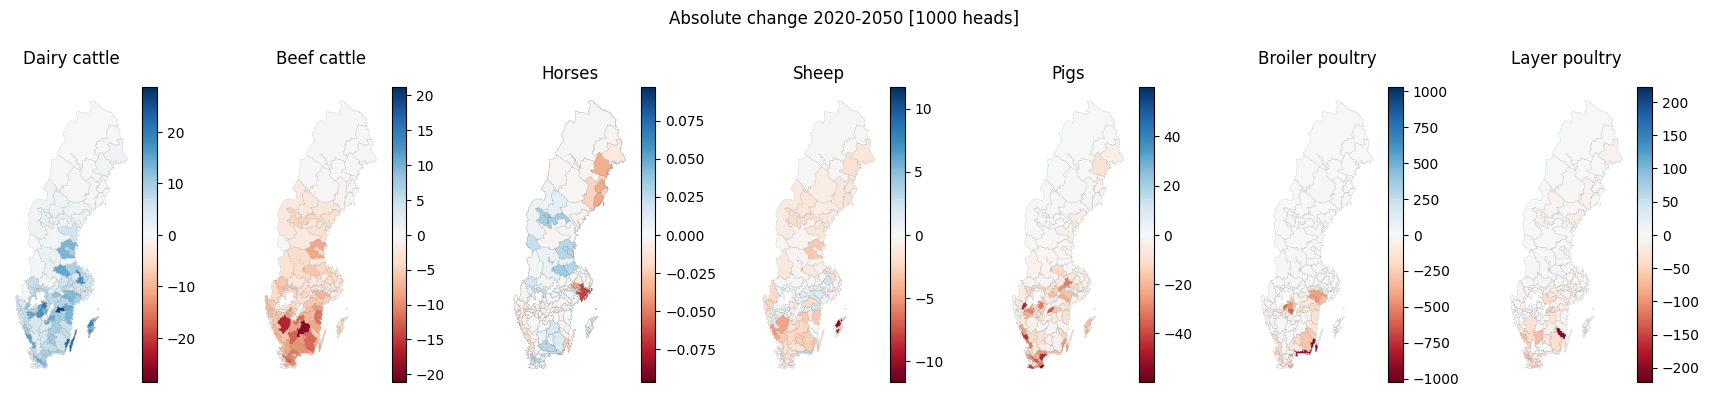

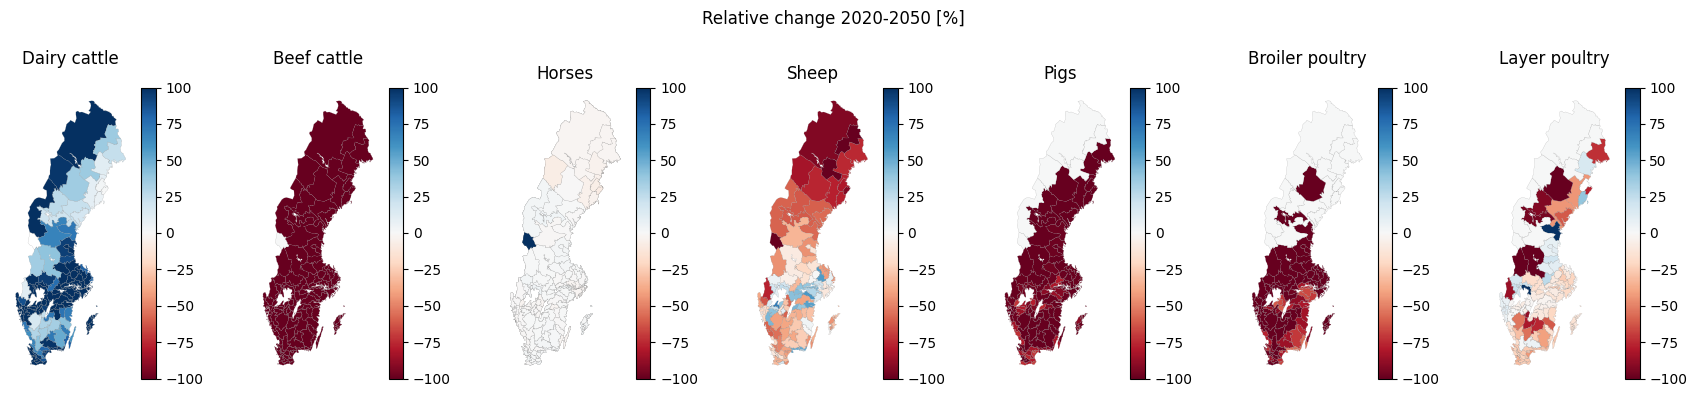

FAT
---


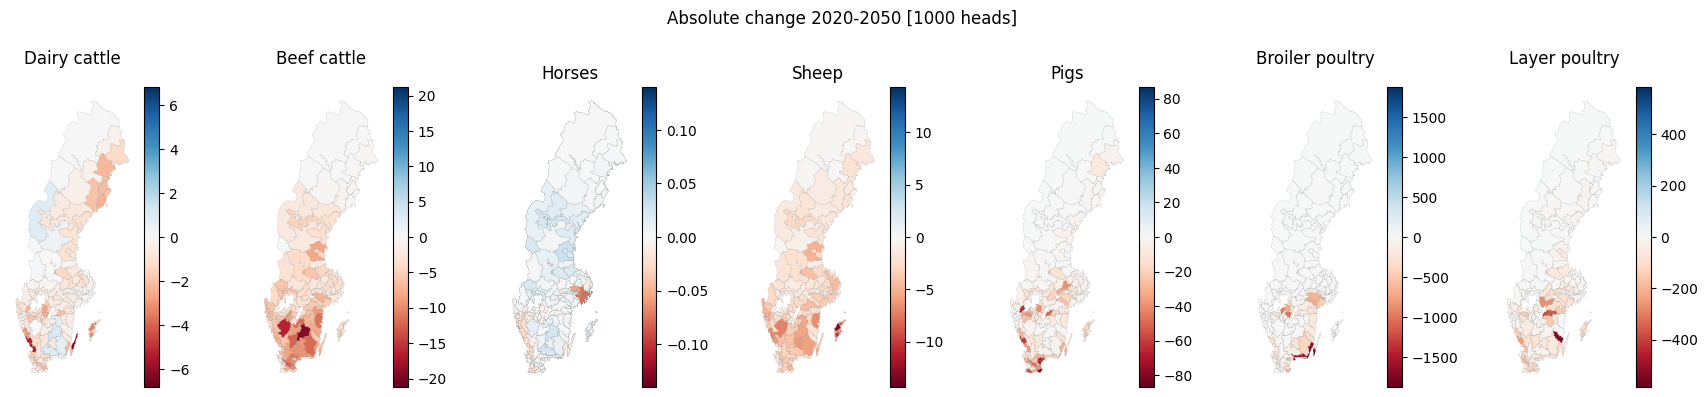

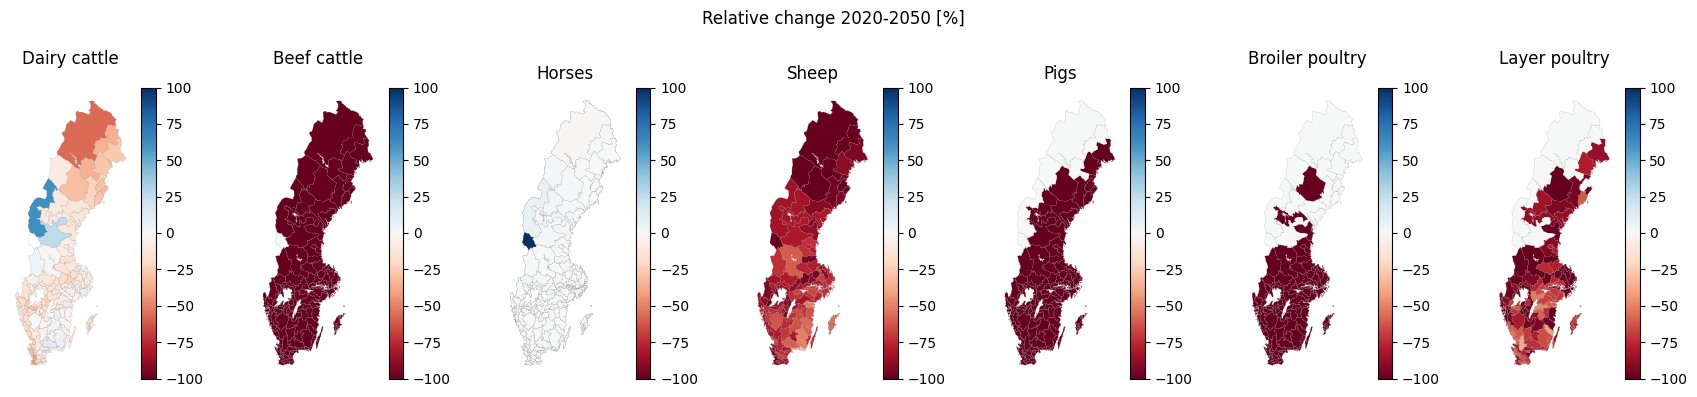

FF
--


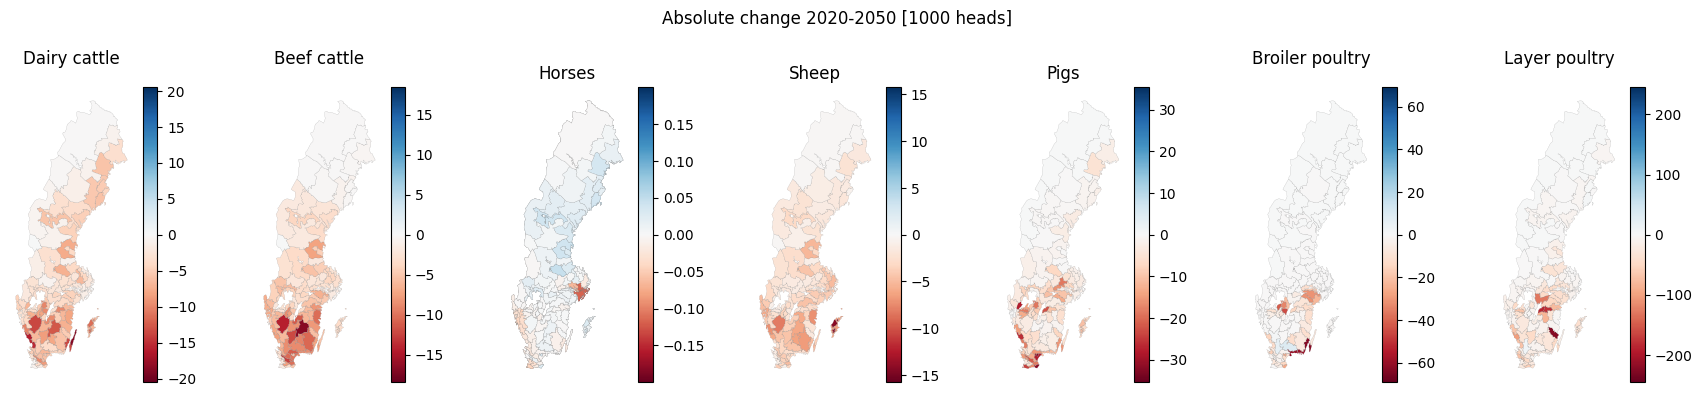

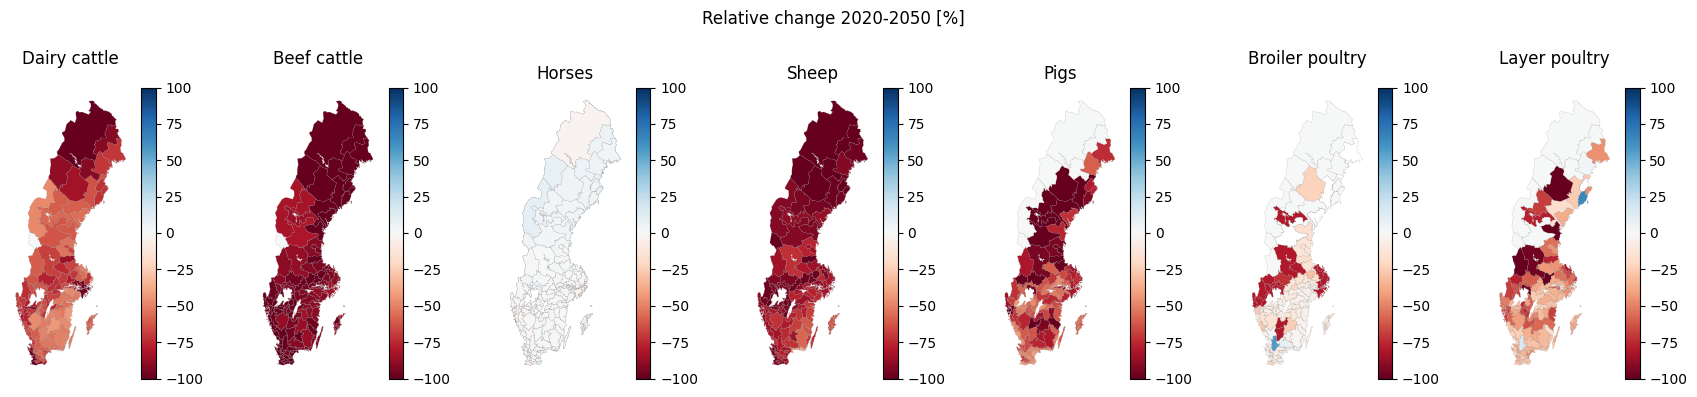

FAI_no_cows
-----------


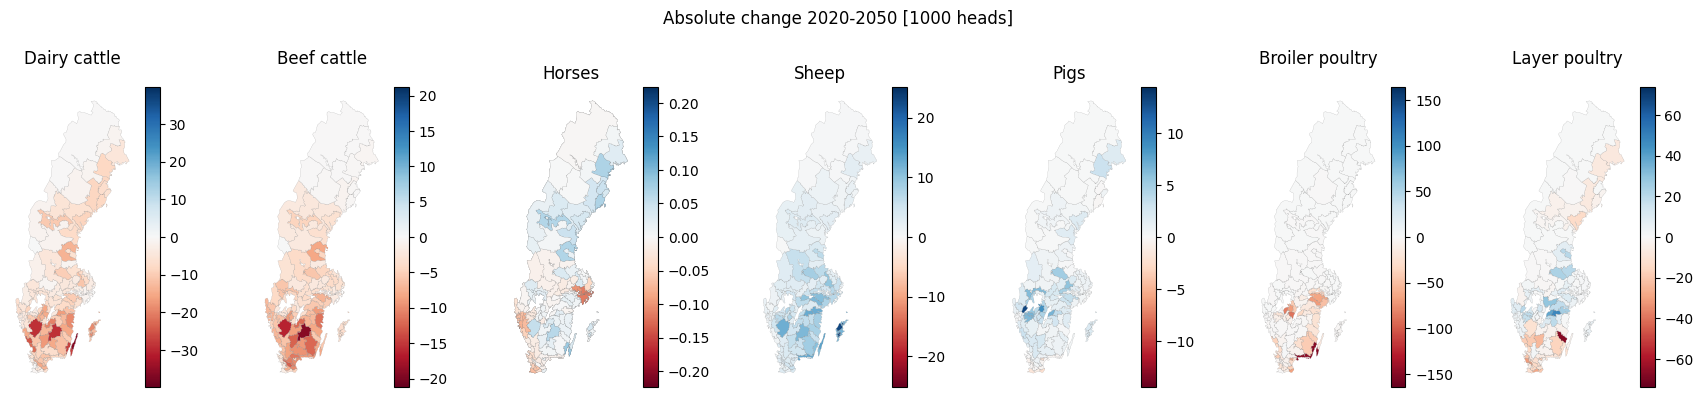

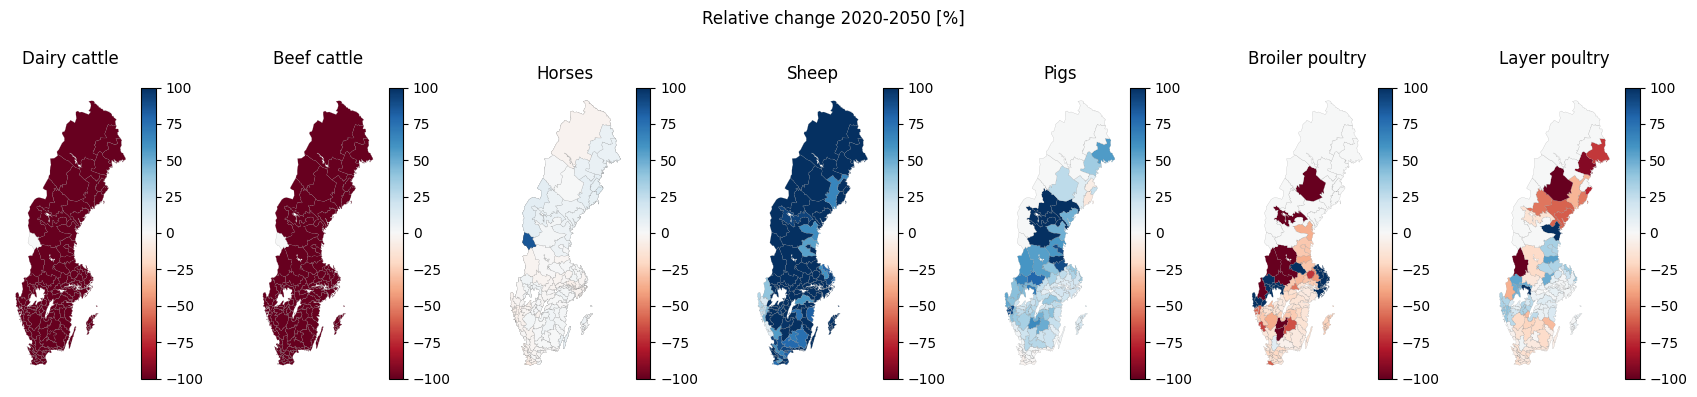

In [12]:
selection = {
    'Dairy cattle':('cattle','dairy'),
    'Beef cattle':('cattle','beef'),
    'Horses':('horses',slice(None)),
    'Sheep':('sheep',slice(None)),
    'Pigs':('pigs',slice(None)),
    'Broiler poultry':('poultry','broiler'),
    'Layer poultry':('poultry','layer')
}

y0 = session.scenarios()['baseline'][0]

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))

    yend = session.scenarios()[scn][-1]
    
    plot_data = session.get_attr('A','heads',['species','breed','region'])/1000
    plot_data_abs = (plot_data.loc[scn,yend] - plot_data.loc['baseline',y0]).sort_index()
    plot_data_prc = ((plot_data.loc[scn,yend] - plot_data.loc['baseline',y0]) / plot_data.loc['baseline',y0] * 100).sort_index().fillna(0)
    
    # ABSOLUTE
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_abs.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-lim*1.1,
            vmax=lim*1.1,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)  
    plt.suptitle(f'Absolute change {y0}-{yend} [1000 heads]')
    plt.tight_layout()
    plt.show()
    
    # PERCENT
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_prc.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-100,
            vmax=100,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)
    plt.suptitle(f'Relative change {y0}-{yend} [%]')
    plt.tight_layout()
    plt.show()